# Vehicle Loan Prediction Machine Learning Model
## Load and Clean the Data

In [169]:
## Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [170]:
# load data
loan_df = pd.read_csv('vehicle_loans.csv', index_col='UNIQUEID')

In [171]:
loan_df.head(10)

,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
UNIQUEID,,,,,,,,,,,,,,,,,,,,,
420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,03-08-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,26-09-2018,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
417566,53278,61360,89.63,67,22807,45,1497,24-08-1985,Self employed,01-08-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
624493,57513,66113,88.48,67,22807,45,1501,30-12-1993,Self employed,26-10-2018,...,0,0,31,0,0,0,0yrs 8mon,1yrs 3mon,1,1
539055,52378,60300,88.39,67,22807,45,1495,09-12-1977,Self employed,26-09-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,1,1
518279,54513,61900,89.66,67,22807,45,1501,08-09-1990,Self employed,19-09-2018,...,0,0,1347,0,0,0,1yrs 9mon,2yrs 0mon,0,0
529269,46349,61500,76.42,67,22807,45,1502,01-06-1988,Salaried,23-09-2018,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
510278,43894,61900,71.89,67,22807,45,1501,04-10-1989,Salaried,16-09-2018,...,0,0,0,0,0,0,0yrs 2mon,0yrs 2mon,0,0
490213,53713,61973,89.56,67,22807,45,1497,15-11-1991,Self employed,05-09-2018,...,0,0,0,0,0,0,4yrs 8mon,4yrs 8mon,1,0


In [172]:
loan_df.shape

(233154, 40)

In [173]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   DISBURSED_AMOUNT                     233154 non-null  int64  
 1   ASSET_COST                           233154 non-null  int64  
 2   LTV                                  233154 non-null  float64
 3   BRANCH_ID                            233154 non-null  int64  
 4   SUPPLIER_ID                          233154 non-null  int64  
 5   MANUFACTURER_ID                      233154 non-null  int64  
 6   CURRENT_PINCODE_ID                   233154 non-null  int64  
 7   DATE_OF_BIRTH                        233154 non-null  object 
 8   EMPLOYMENT_TYPE                      225493 non-null  object 
 9   DISBURSAL_DATE                       233154 non-null  object 
 10  STATE_ID                             233154 non-null  int64  
 11  EMPLOYEE_CODE

In [174]:
# loan_df['DISBURSAL_DATE'] = pd.to_datetime(loan_df['DISBURSAL_DATE'], infer_datetime_format=True, errors='coerce') - old version to fix date type errors
loan_df['DISBURSAL_DATE'] = pd.to_datetime(loan_df['DISBURSAL_DATE'], format='mixed')



In [175]:
loan_df['DISBURSAL_DATE'].info()

<class 'pandas.core.series.Series'>
Index: 233154 entries, 420825 to 630213
Series name: DISBURSAL_DATE
Non-Null Count   Dtype         
--------------   -----         
233154 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.6 MB


In [176]:
print(f"Maximum Disbursal Date: {loan_df['DISBURSAL_DATE'].max()} \n"
      f"Minimum Disbursal Date: {loan_df['DISBURSAL_DATE'].min()} \n"
      f"Timespan of Data Set:   {loan_df['DISBURSAL_DATE'].max() - loan_df['DISBURSAL_DATE'].min()}")

Maximum Disbursal Date: 2018-12-10 00:00:00 
Minimum Disbursal Date: 2018-01-08 00:00:00 
Timespan of Data Set:   336 days 00:00:00


## Target Variable

- Variable we are trying to predict
- LOAN_DEFAULT is our target variable so lets investigate it further

In [177]:
loan_df['LOAN_DEFAULT'].value_counts()

LOAN_DEFAULT
0    182543
1     50611
Name: count, dtype: int64

In [178]:
# target normalized
loan_df['LOAN_DEFAULT'].value_counts(normalize=True)

LOAN_DEFAULT
0    0.782929
1    0.217071
Name: proportion, dtype: float64

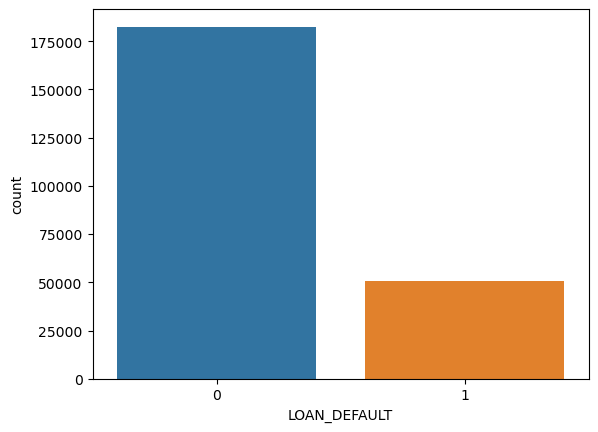

In [179]:
# plot loan default 
sns.countplot(x='LOAN_DEFAULT', data=loan_df)
plt.show()

## Missing Values

### Identifying Missing Data

In [180]:
loan_df.isnull().sum()

DISBURSED_AMOUNT                          0
ASSET_COST                                0
LTV                                       0
BRANCH_ID                                 0
SUPPLIER_ID                               0
MANUFACTURER_ID                           0
CURRENT_PINCODE_ID                        0
DATE_OF_BIRTH                             0
EMPLOYMENT_TYPE                        7661
DISBURSAL_DATE                            0
STATE_ID                                  0
EMPLOYEE_CODE_ID                          0
MOBILENO_AVL_FLAG                         0
AADHAR_FLAG                               0
PAN_FLAG                                  0
VOTERID_FLAG                              0
DRIVING_FLAG                              0
PASSPORT_FLAG                             0
PERFORM_CNS_SCORE                         0
PERFORM_CNS_SCORE_DESCRIPTION             0
PRI_NO_OF_ACCTS                           0
PRI_ACTIVE_ACCTS                          0
PRI_OVERDUE_ACCTS               

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Name: count, dtype: int64


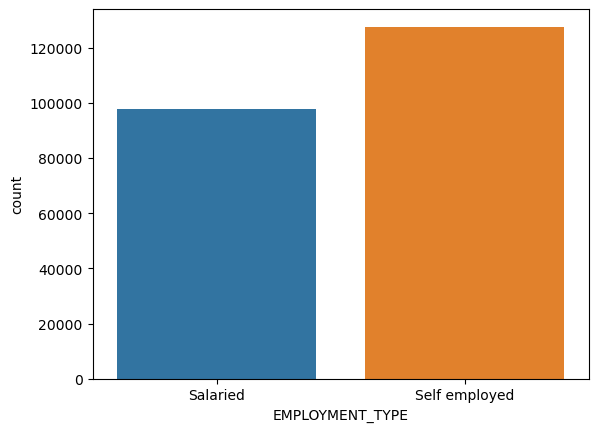

In [181]:
print(loan_df['EMPLOYMENT_TYPE'].value_counts())
sns.countplot(x="EMPLOYMENT_TYPE", data=loan_df)
plt.show()

In [182]:
loan_df = loan_df.fillna(value={'EMPLOYMENT_TYPE' : 'Missing'})

EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Missing            7661
Name: count, dtype: int64


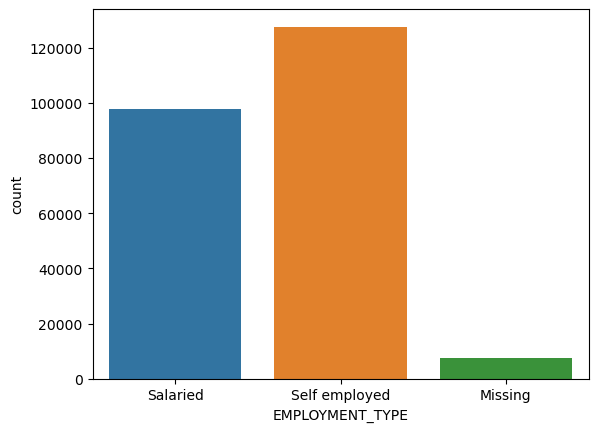

In [183]:
print(loan_df['EMPLOYMENT_TYPE'].value_counts())
sns.countplot(x="EMPLOYMENT_TYPE", data=loan_df)
plt.show()

## Dealing with Dates

- We have two date columns, DISBURSAL_DATE and DATE_OF_BIRTH
- These should be transformed into a more algorithm friendly format

In [184]:
# make sure thic colums are datetimes
loan_df['DATE_OF_BIRTH'] = pd.to_datetime(loan_df['DATE_OF_BIRTH'],format='mixed')
loan_df['DISBURSAL_DATE'] = pd.to_datetime(loan_df['DISBURSAL_DATE'],format='mixed')

print("DATE_OF_BIRTH variable type: ", loan_df['DATE_OF_BIRTH'].dtypes)
print("DISBURSAL_DATE variable type: ", loan_df['DISBURSAL_DATE'].dtypes)

DATE_OF_BIRTH variable type:  datetime64[ns]
DISBURSAL_DATE variable type:  datetime64[ns]


In [185]:
# calculate differences between them
loan_df['AGE'] = (loan_df['DISBURSAL_DATE'] - loan_df['DATE_OF_BIRTH']).dt.days // 365

#check result
print(loan_df[['DATE_OF_BIRTH', 'AGE', 'DISBURSAL_DATE']].sample(n=5))

         DATE_OF_BIRTH  AGE DISBURSAL_DATE
UNIQUEID                                  
552549      1996-08-31   22     2018-09-30
579019      1991-12-10   26     2018-10-15
601001      1991-05-10   27     2018-10-22
491045      1987-01-01   31     2018-05-09
602449      1991-08-17   27     2018-10-22


### Disbursal Month
### EXERCISE 
- Can you create a new column 'DISBURSAL_MONTH' to store the disbursal month as an integer

In [186]:
loan_df['DISBURSAL_MONTH'] = loan_df['DISBURSAL_DATE'].dt.month
loan_df['DISBURSAL_MONTH'].value_counts()

DISBURSAL_MONTH
10    84875
8     56975
9     54443
11     6709
6      5991
12     5613
3      5148
4      4627
7      4150
5      2890
1      1708
2        25
Name: count, dtype: int64

In [187]:
loan_df = loan_df.drop(['DISBURSAL_DATE', 'DATE_OF_BIRTH'], axis=1)

## Fix the Strings

- AVERAGE_ACCT_AGE and CREDIT_HISTORY_LENGTH were also strings 
- Column names suggest they should be numeric, let's take a look 

### String Fields

- Can select a subset of DataFrame columns by passing in a list of column names,  [indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html)
- [df.sample](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) can be used to pull a random sample of n rows

In [188]:
loan_df[['CREDIT_HISTORY_LENGTH', 'AVERAGE_ACCT_AGE']].sample(n=10)

,CREDIT_HISTORY_LENGTH,AVERAGE_ACCT_AGE
UNIQUEID,,
545711,0yrs 5mon,0yrs 3mon
517632,0yrs 0mon,0yrs 0mon
448955,2yrs 5mon,1yrs 6mon
507263,5yrs 4mon,2yrs 3mon
562387,2yrs 1mon,1yrs 7mon
623133,0yrs 6mon,0yrs 6mon
537820,3yrs 9mon,1yrs 6mon
452998,0yrs 6mon,0yrs 6mon
650633,1yrs 0mon,0yrs 5mon


### String Manipulation

The current format of AVERAGE_ACCT_AGE and CREDIT_HISTORY_LENGTH is not useful

### EXERCISE

- Can you create a new column 'AVERAGE_ACCT_AGE_MONTHS' to store the average account age as an integer of months?

### Steps:
- Create a function which can calculate the total number of months based on a list of input strings
- Extract the relevant numbers from the original string data
- Use map to perform calc_months across all rows
- Check the results

In [189]:
#The calc_months function simply takes the list of two numbers stored in AVERAGE_ACCT_AGE_MONTHS
def calc_months(str_list):  
    years = int(str_list[0])
    months = int(str_list[1])

    num_months = (years * 12) + months
    return num_months

In [190]:
# str.findall can be used to find all instances of a string within a column
# the '\d+' is a regular expression which finds integers in a string

loan_df['AVERAGE_ACCT_AGE_MONTHS'] = loan_df['AVERAGE_ACCT_AGE'].str.findall('\d+')
print(loan_df['AVERAGE_ACCT_AGE_MONTHS'].sample(n=10))

UNIQUEID
614800     [0, 0]
586960     [1, 1]
553557     [0, 0]
475545     [2, 2]
510412     [1, 1]
550290     [0, 0]
491750     [0, 0]
513978     [1, 3]
536466    [3, 10]
622002     [1, 2]
Name: AVERAGE_ACCT_AGE_MONTHS, dtype: object


In [191]:
# Used map to apply a function which calculates the total number of months for each row in the dataframe
loan_df['AVERAGE_ACCT_AGE_MONTHS'] = loan_df['AVERAGE_ACCT_AGE_MONTHS'].map(calc_months)

### Step 4 - Inspect the results

In [192]:
# check results
print(loan_df[['AVERAGE_ACCT_AGE_MONTHS', 'AVERAGE_ACCT_AGE']].sample(n=10))

          AVERAGE_ACCT_AGE_MONTHS AVERAGE_ACCT_AGE
UNIQUEID                                          
565008                          0        0yrs 0mon
420387                          0        0yrs 0mon
618953                          0        0yrs 0mon
616726                          5        0yrs 5mon
560941                          0        0yrs 0mon
652651                          0        0yrs 0mon
465124                         11       0yrs 11mon
628020                          0        0yrs 0mon
483792                          0        0yrs 0mon
489070                         17        1yrs 5mon


### More String Manipulation

- Great, now we have fixed AVERAGE_ACCT_AGE how about CREDIT_HISTORY_LENGTH?
- We could simply copy and paste our solution from the previous exercise
- How about if we had 20 columns to fix instead of 2?

### EXERCISE

- Convert your solution to the previous exercise into a function and use it to fix CREDIT_HISTORY_LENGTH

In [193]:
def convert_str_to_months(col_name):
    new_col = col_name + '_MONTHS'
    loan_df[new_col] = loan_df[col_name].str.findall('\d+')
    loan_df[new_col] = loan_df[new_col].map(calc_months)

In [194]:
# check function
convert_str_to_months('CREDIT_HISTORY_LENGTH')
loan_df[['CREDIT_HISTORY_LENGTH_MONTHS', 'CREDIT_HISTORY_LENGTH']].sample(n=5)

,CREDIT_HISTORY_LENGTH_MONTHS,CREDIT_HISTORY_LENGTH
UNIQUEID,,
508215,36,3yrs 0mon
454125,0,0yrs 0mon
600253,0,0yrs 0mon
600415,0,0yrs 0mon
617551,0,0yrs 0mon


In [195]:
# drop the 'AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH' columns
loan_df = loan_df.drop(['AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH'], axis=1)

In [196]:
loan_df['PERFORM_CNS_SCORE_DESCRIPTION'].value_counts()

PERFORM_CNS_SCORE_DESCRIPTION
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk                                                  3748
Not Scored: Not Enough Info available on the c

# Exploratory Data Analysis

In [197]:
# get info 
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 233154 entries, 420825 to 630213
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   DISBURSED_AMOUNT                     233154 non-null  int64  
 1   ASSET_COST                           233154 non-null  int64  
 2   LTV                                  233154 non-null  float64
 3   BRANCH_ID                            233154 non-null  int64  
 4   SUPPLIER_ID                          233154 non-null  int64  
 5   MANUFACTURER_ID                      233154 non-null  int64  
 6   CURRENT_PINCODE_ID                   233154 non-null  int64  
 7   EMPLOYMENT_TYPE                      233154 non-null  object 
 8   STATE_ID                             233154 non-null  int64  
 9   EMPLOYEE_CODE_ID                     233154 non-null  int64  
 10  MOBILENO_AVL_FLAG                    233154 non-null  int64  
 11  AADHAR_FLAG  

### Unique Values 

In [198]:
loan_df.nunique()

DISBURSED_AMOUNT                       24565
ASSET_COST                             46252
LTV                                     6579
BRANCH_ID                                 82
SUPPLIER_ID                             2953
MANUFACTURER_ID                           11
CURRENT_PINCODE_ID                      6698
EMPLOYMENT_TYPE                            3
STATE_ID                                  22
EMPLOYEE_CODE_ID                        3270
MOBILENO_AVL_FLAG                          1
AADHAR_FLAG                                2
PAN_FLAG                                   2
VOTERID_FLAG                               2
DRIVING_FLAG                               2
PASSPORT_FLAG                              2
PERFORM_CNS_SCORE                        573
PERFORM_CNS_SCORE_DESCRIPTION             20
PRI_NO_OF_ACCTS                          108
PRI_ACTIVE_ACCTS                          40
PRI_OVERDUE_ACCTS                         22
PRI_CURRENT_BALANCE                    71341
PRI_SANCTI

In [199]:
#MOBILE_AVL_FLAG has only one unique value
loan_df['MOBILENO_AVL_FLAG'].value_counts()

MOBILENO_AVL_FLAG
1    233154
Name: count, dtype: int64

In [200]:
# MOBILENO_AVL_FLAG rows contains the value 1, drop it
loan_df = loan_df.drop(['MOBILENO_AVL_FLAG'], axis = 1)

In [201]:
# EDA for IDs column
loan_df[['SUPPLIER_ID', 'CURRENT_PINCODE_ID', 'EMPLOYEE_CODE_ID', 'BRANCH_ID', 'STATE_ID', 'MANUFACTURER_ID']].sample(6)

,SUPPLIER_ID,CURRENT_PINCODE_ID,EMPLOYEE_CODE_ID,BRANCH_ID,STATE_ID,MANUFACTURER_ID
UNIQUEID,,,,,,
448689,20470,3382,533,138,9,86
425187,22275,1084,1436,34,6,86
648514,14834,2378,3393,2,4,86
549991,17141,2029,369,85,4,120
445545,22909,2230,1995,249,4,51
626886,15218,1010,3464,130,6,86


In [202]:
# Id fields with large numbers of unique values will introduce complexity into our predictive model. Drop them
loan_df = loan_df.drop(['SUPPLIER_ID', 'CURRENT_PINCODE_ID', 'EMPLOYEE_CODE_ID', 'BRANCH_ID'], axis=1)

### EXERCISE 

- Pick one of the two remaining Id columns and write some code to investigate its unique values


MANUFACTURER_ID
86     109534
45      56626
51      27204
48      16710
49      10220
120      9658
67       2405
145       778
153        12
152         6
156         1
Name: count, dtype: int64
MANUFACTURER_ID
86     0.469792
45     0.242870
51     0.116678
48     0.071669
49     0.043834
120    0.041423
67     0.010315
145    0.003337
153    0.000051
152    0.000026
156    0.000004
Name: proportion, dtype: float64


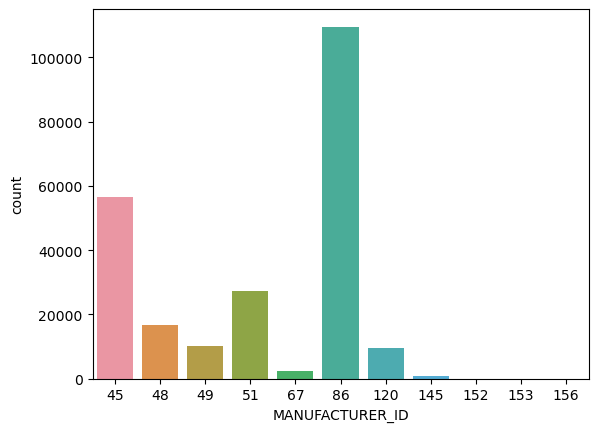

In [203]:
print(loan_df['MANUFACTURER_ID'].value_counts())
print(loan_df['MANUFACTURER_ID'].value_counts(normalize=True))
sns.countplot(x="MANUFACTURER_ID", data=loan_df)
plt.show()

In [204]:
# how loan defaults are distributed within manufacturer groups
loan_df.groupby('MANUFACTURER_ID')['LOAN_DEFAULT'].value_counts(normalize=True).unstack(level=-1)


LOAN_DEFAULT,0,1
MANUFACTURER_ID,,
45,0.771501,0.228499
48,0.727469,0.272531
49,0.781213,0.218787
51,0.792053,0.207947
67,0.782536,0.217464
86,0.795406,0.204594
120,0.779250,0.220750
145,0.799486,0.200514
152,1.000000,NaN


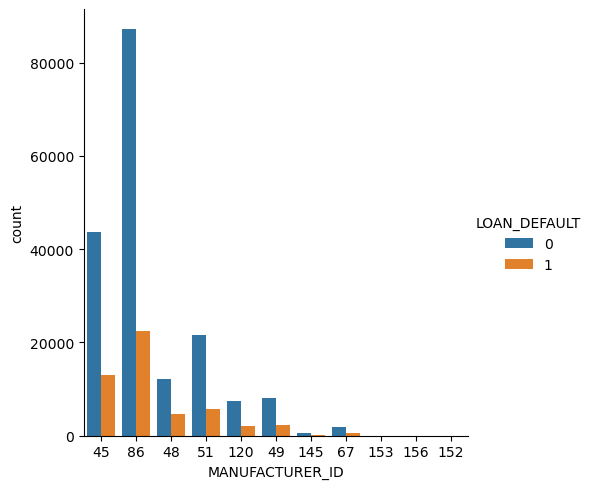

In [205]:
loan_df['MANUFACTURER_ID'] = loan_df['MANUFACTURER_ID'].astype(str)
loan_df['LOAN_DEFAULT'] = loan_df['LOAN_DEFAULT'].astype(str)

sns.catplot(data=loan_df,kind='count',x='MANUFACTURER_ID',hue='LOAN_DEFAULT')
plt.show()

## Reusable EDA

We still have 4 categorical variables to investigate!
- EMPLOYMENT_TYPE: Employment Type of the customer
- PERFORM_CNS_SCORE_DESCRIPTION: Bureau score description 
- STATE_ID: State of disbursement 
- DISBURSAL_MONTH: The month in which the loan was disbursed

In [206]:
# before i convert this columns (for test) astype(str) to avoid mistakes 'numpy.int64' object has no attribute 'startswith'
loan_df['EMPLOYMENT_TYPE'] = loan_df['EMPLOYMENT_TYPE'].astype(str)
loan_df['PERFORM_CNS_SCORE_DESCRIPTION'] = loan_df['PERFORM_CNS_SCORE_DESCRIPTION'].astype(str)
loan_df['STATE_ID'] = loan_df['STATE_ID'].astype(str)
loan_df['DISBURSAL_MONTH'] = loan_df['DISBURSAL_MONTH'].astype(str)


### EXERCISE 

- Write a function to perform the steps from lesson 2 for any column 
- Use this to explore the remaining categorical variables and think about their relationships with the target 

In [207]:
def explore_categorical(col_name):   
    print("{0} Summary".format(col_name))
    print("\n")

    print("{0} Counts".format(col_name))
    print(loan_df[col_name].value_counts())
    print("\n")

    print("{0} Ratio".format(col_name))
    print(loan_df[col_name].value_counts(normalize=True))
    print("\n")

    print("{0} Default Counts".format(col_name))
    print(loan_df.groupby(col_name)['LOAN_DEFAULT'].value_counts().unstack(level=-1))
    print("\n")

    print("{0} Default Ratio".format(col_name))
    print(loan_df.groupby(col_name)['LOAN_DEFAULT'].value_counts(normalize=True).unstack(level=-1))
    print("\n")

    sns.catplot(data=loan_df,kind='count',x=col_name,hue='LOAN_DEFAULT')
    plt.show()

DISBURSAL_MONTH Summary


DISBURSAL_MONTH Counts
DISBURSAL_MONTH
10    84875
8     56975
9     54443
11     6709
6      5991
12     5613
3      5148
4      4627
7      4150
5      2890
1      1708
2        25
Name: count, dtype: int64


DISBURSAL_MONTH Ratio
DISBURSAL_MONTH
10    0.364030
8     0.244366
9     0.233507
11    0.028775
6     0.025695
12    0.024074
3     0.022080
4     0.019845
7     0.017799
5     0.012395
1     0.007326
2     0.000107
Name: proportion, dtype: float64


DISBURSAL_MONTH Default Counts
LOAN_DEFAULT         0      1
DISBURSAL_MONTH              
1                 1316    392
10               64474  20401
11                5484   1225
12                4470   1143
2                   23      2
3                 4094   1054
4                 3636    991
5                 2279    611
6                 4697   1294
7                 3222    928
8                44938  12037
9                43910  10533


DISBURSAL_MONTH Default Ratio
LOAN_DEFAULT            0  

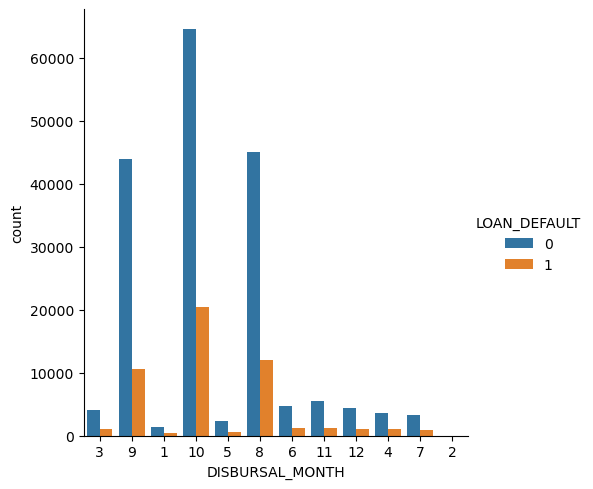

In [208]:
# test the explore_categorical function

explore_categorical("DISBURSAL_MONTH")

## Continuous Variables 

### Summary Statistics

In [209]:
loan_df["AGE"].describe()

count    233154.000000
mean         33.918037
std           9.831623
min          17.000000
25%          26.000000
50%          32.000000
75%          41.000000
max          69.000000
Name: AGE, dtype: float64

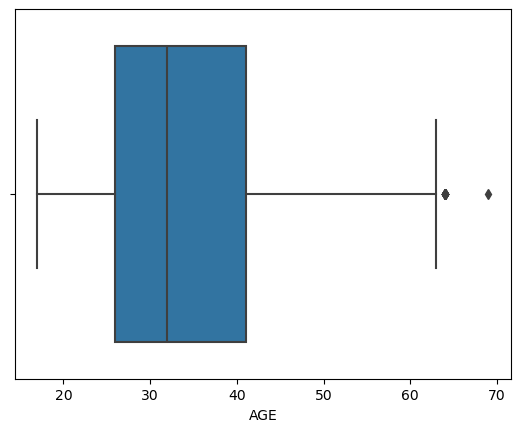

In [210]:
sns.boxplot(x="AGE", data=loan_df)
plt.show()

In [211]:
loan_df.groupby('LOAN_DEFAULT')['AGE'].describe()

,count,mean,std,min,25%,50%,75%,max
LOAN_DEFAULT,,,,,,,,
0,182543.0,34.106391,9.863022,17.0,26.0,32.0,41.0,69.0
1,50611.0,33.238683,9.687248,17.0,25.0,31.0,40.0,64.0


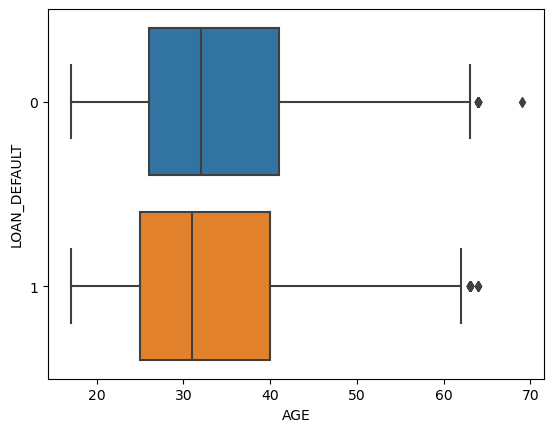

In [212]:
sns.boxplot(x='AGE', y='LOAN_DEFAULT', data=loan_df, orient="h")
plt.show()

### EXERCISE 

- Using the steps we have performed to explore ‘AGE’, write a function that can be used to explore other continuous variables
- Pick a few more continuous variables to explore and use your function to investigate them!
- Keep a note of your findings

In [215]:
def explore_continuous(col_name):
    #print statistical summary
    print("{0} Summary".format(col_name))
    print("\n")
    print(loan_df[col_name].describe())
    print("\n")

    #Look at boxplot
    sns.boxplot(x=col_name, data=loan_df)
    plt.show()

    #Now lets look deeper by grouping with the target variable 
    print("{0} Grouped Summary".format(col_name))
    print("\n")
    print(loan_df.groupby('LOAN_DEFAULT')[col_name].describe())

    #look at grouped boxplot 
    sns.boxplot(x=col_name, y='LOAN_DEFAULT', data=loan_df, orient="h")
    plt.show()

DISBURSED_AMOUNT Summary


count    233154.000000
mean      54356.993528
std       12971.314171
min       13320.000000
25%       47145.000000
50%       53803.000000
75%       60413.000000
max      990572.000000
Name: DISBURSED_AMOUNT, dtype: float64




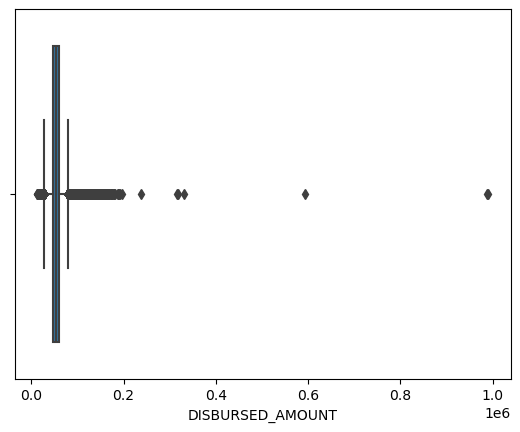

DISBURSED_AMOUNT Grouped Summary


                 count          mean           std      min      25%      50%  \
LOAN_DEFAULT                                                                    
0             182543.0  53826.471111  13140.699007  13320.0  46369.0  53303.0   
1              50611.0  56270.473869  12150.255527  13369.0  49303.0  55459.0   

                  75%       max  
LOAN_DEFAULT                     
0             59947.0  990572.0  
1             61947.0  191392.0  


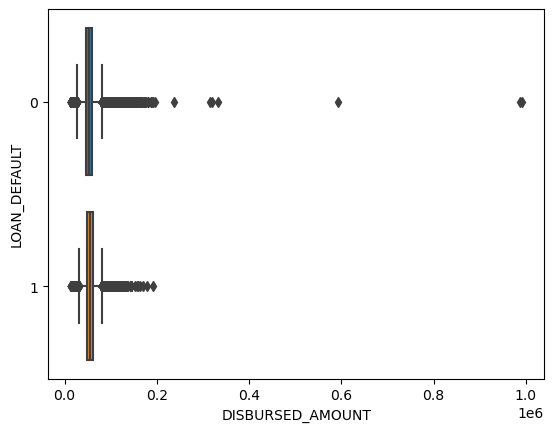

In [216]:
explore_continuous('DISBURSED_AMOUNT')